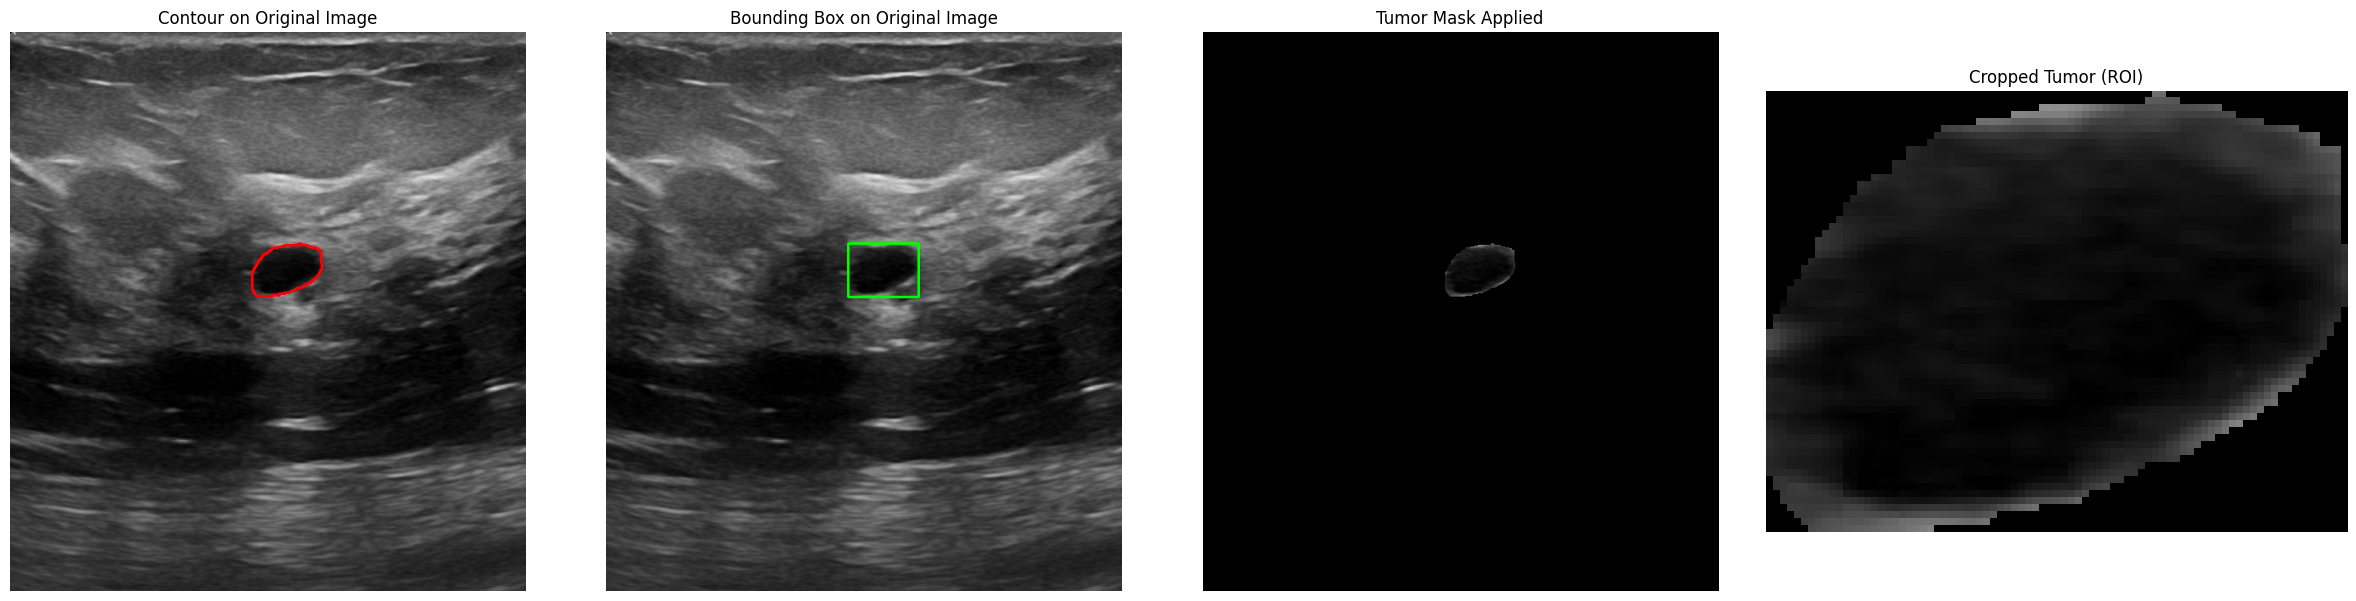

Image path: BUSI_Jpeg/benign/benign (63).png
Mask path : BUSI_Jpeg/benign_mask/benign (63)_mask.png
Bounding box -> x=285, y=250, w=83, h=63


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Choose one sample (change class_name / sample_id anytime) ---
base_dir = Path("BUSI_Jpeg")
class_name = "benign"      # options: benign, malignant
sample_id = 63               # example -> benign (1).png

img_path = base_dir / class_name / f"{class_name} ({sample_id}).png"
mask_path = base_dir / f"{class_name}_mask" / f"{class_name} ({sample_id})_mask.png"

if not img_path.exists() or not mask_path.exists():
    raise FileNotFoundError(
        f"Image or mask not found.\nImage: {img_path}\nMask: {mask_path}"
    )

# --- Read image and mask ---
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)

# --- Find tumor contour from mask ---
contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    raise ValueError("No contour found in mask image.")

# pick the largest contour (main tumor)
largest_contour = max(contours, key=cv2.contourArea)

# --- 1) Draw contour on original image ---
contour_vis = img_rgb.copy()
cv2.drawContours(contour_vis, [largest_contour], -1, (255, 0, 0), 2)

# --- 2) Bounding box from contour ---
x, y, w, h = cv2.boundingRect(largest_contour)
bbox_vis = img_rgb.copy()
cv2.rectangle(bbox_vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

# --- 3) Tumor-only masked image + cropped tumor ROI ---
masked_tumor = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_bin)
cropped_tumor = masked_tumor[y:y + h, x:x + w]

# --- Plot results ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(contour_vis)
axes[0].set_title("Contour on Original Image")
axes[0].axis("off")

axes[1].imshow(bbox_vis)
axes[1].set_title("Bounding Box on Original Image")
axes[1].axis("off")

axes[2].imshow(masked_tumor)
axes[2].set_title("Tumor Mask Applied")
axes[2].axis("off")

axes[3].imshow(cropped_tumor)
axes[3].set_title("Cropped Tumor (ROI)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"Image path: {img_path}")
print(f"Mask path : {mask_path}")
print(f"Bounding box -> x={x}, y={y}, w={w}, h={h}")

Using model: yolo26n.pt
Dataset samples (paired): 647
- benign: 437
- malignant: 210
Held-out test pool (~30%): 195
Evaluated now (capped): 195
YOLO conf fallback chain: (0.15, 0.1, 0.01)
Overall detection accuracy (IoU>=0.5): 20.00%
Mean IoU: 0.1872


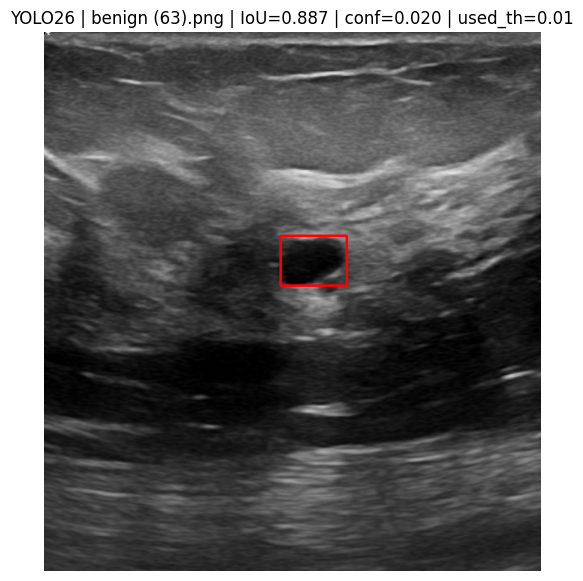

In [ ]:
# YOLO26 detection + connected evaluation (with timing / FPS)
# This cell expects `base_dir`, `class_name`, and `sample_id` from the top cell.
import random
import time
from ultralytics import YOLO

if "base_dir" not in globals() or "class_name" not in globals() or "sample_id" not in globals():
    raise ValueError("Run the top cell first so base_dir, class_name, and sample_id are defined.")

model_path = Path("yolo26n.pt")
if not model_path.exists():
    raise FileNotFoundError("yolo26n.pt not found in project root.")

model = YOLO(str(model_path))
print(f"Using model: {model_path}")

img_dirs = [base_dir / "benign", base_dir / "malignant"]
mask_dirs = {
    "benign": base_dir / "benign_mask",
    "malignant": base_dir / "malignant_mask",
}

# Build (image, mask) pairs
pairs = []
for img_dir in img_dirs:
    cls = img_dir.name
    mask_dir = mask_dirs[cls]
    for img_path in sorted(img_dir.glob("*.png")):
        mask_path = mask_dir / f"{img_path.stem}_mask.png"
        if mask_path.exists():
            pairs.append((img_path, mask_path, cls))

if not pairs:
    raise ValueError("No image/mask pairs found in BUSI_Jpeg.")

random.seed(42)
random.shuffle(pairs)

# Lighter evaluation setup
TEST_RATIO = 0.3
MAX_EVAL_SAMPLES = 200  # keep runtime short
YOLO_CONF_THRESHOLDS = (0.25, 0.10, 0.03, 0.01, 0.003)
YOLO_IMGSZ = 960

split_idx = int((1 - TEST_RATIO) * len(pairs))
test_pairs = pairs[split_idx:] if split_idx < len(pairs) else pairs
if not test_pairs:
    test_pairs = pairs

eval_pairs = test_pairs[:MAX_EVAL_SAMPLES]


def get_gt_bbox(mask_path: Path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return np.array([x, y, x + w, y + h], dtype=float)


def iou_xyxy(a, b):
    xA = max(a[0], b[0])
    yA = max(a[1], b[1])
    xB = min(a[2], b[2])
    yB = min(a[3], b[3])
    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter = inter_w * inter_h
    if inter <= 0:
        return 0.0
    area_a = max(0.0, (a[2] - a[0])) * max(0.0, (a[3] - a[1]))
    area_b = max(0.0, (b[2] - b[0])) * max(0.0, (b[3] - b[1]))
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def enhance_for_yolo(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blur = cv2.GaussianBlur(enhanced, (0, 0), 1.2)
    sharp = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)
    return cv2.cvtColor(sharp, cv2.COLOR_GRAY2BGR)


def predict_box(img_path: Path, conf_thresholds=YOLO_CONF_THRESHOLDS, imgsz=YOLO_IMGSZ):
    raw_bgr = cv2.imread(str(img_path))
    if raw_bgr is None:
        return None, 0.0, None, "none"

    variants = [
        ("original", raw_bgr),
        ("enhanced", enhance_for_yolo(raw_bgr)),
    ]

    best_box, best_conf, best_th, best_variant = None, -1.0, None, "none"
    for variant_name, variant_bgr in variants:
        for conf_threshold in conf_thresholds:
            results = model.predict(source=variant_bgr, conf=conf_threshold, imgsz=imgsz, verbose=False)
            boxes = results[0].boxes
            if boxes is None or len(boxes) == 0:
                continue

            confs = boxes.conf.cpu().numpy()
            xyxy = boxes.xyxy.cpu().numpy()
            idx = int(np.argmax(confs))
            conf_val = float(confs[idx])
            if conf_val > best_conf:
                best_box = xyxy[idx]
                best_conf = conf_val
                best_th = conf_threshold
                best_variant = variant_name

    if best_box is None:
        return None, 0.0, None, "none"
    return best_box, best_conf, best_th, best_variant


# Overall accuracy on chosen evaluation scope (IoU >= 0.5 is correct) + timing
ious = []
correct = 0
per_sample = []
inference_times = []  # seconds per image (full predict_box, all variants)

for img_path, mask_path, cls in eval_pairs:
    gt = get_gt_bbox(mask_path)

    t0 = time.perf_counter()
    pred, conf, used_th, used_variant = predict_box(img_path)
    inference_times.append(time.perf_counter() - t0)

    if gt is None:
        continue

    iou = 0.0 if pred is None else iou_xyxy(pred, gt)
    is_correct = iou >= 0.5

    correct += int(is_correct)
    ious.append(iou)
    per_sample.append((img_path, gt, pred, conf, iou, is_correct, cls, used_th, used_variant))

if not per_sample:
    raise ValueError("No valid test samples were evaluated.")

overall_accuracy = correct / len(per_sample)
mean_iou = float(np.mean(ious))
mean_inference_ms = float(np.mean(inference_times)) * 1000.0
fps = 1.0 / float(np.mean(inference_times)) if np.mean(inference_times) > 0 else 0.0


# ---- Detection metrics: Precision, Recall, F1, AP@0.5, mAP@0.5:0.95 ----
# Each evaluation image has exactly 1 GT tumor box.
# `predict_box` returns at most 1 prediction (the highest-confidence one).
# scored_samples = (conf, iou) per image; conf=None means no detection.
scored_samples = []
for _img, _gt, pred_box, conf_val, iou_val, _ok, _cls, _th, _var in per_sample:
    if pred_box is None:
        scored_samples.append((None, None))
    else:
        scored_samples.append((float(conf_val), float(iou_val)))

n_gt = len(per_sample)


def detection_pr_ap(scored, n_gt, iou_thr):
    """Single-class detection metrics at one IoU threshold.

    Returns dict with precision, recall, f1, ap, tp, fp, fn at this threshold.
    Uses the standard 11-point interpolated AP (PASCAL VOC).
    """
    preds = [(c, i) for c, i in scored if c is not None]
    preds.sort(key=lambda x: -x[0])

    tp_flags, fp_flags = [], []
    for _conf, iou in preds:
        if iou is not None and iou >= iou_thr:
            tp_flags.append(1); fp_flags.append(0)
        else:
            tp_flags.append(0); fp_flags.append(1)

    tp_cum = np.cumsum(tp_flags) if tp_flags else np.array([0])
    fp_cum = np.cumsum(fp_flags) if fp_flags else np.array([0])

    if tp_flags:
        recalls = tp_cum / max(n_gt, 1)
        precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1)
    else:
        recalls = np.array([0.0])
        precisions = np.array([0.0])

    ap = 0.0
    for r in np.linspace(0, 1, 11):
        mask = recalls >= r
        p_at_r = float(precisions[mask].max()) if mask.any() else 0.0
        ap += p_at_r / 11.0

    tp = int(tp_cum[-1]) if tp_flags else 0
    fp = int(fp_cum[-1]) if fp_flags else 0
    fn = n_gt - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / n_gt if n_gt > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {
        "precision": float(precision), "recall": float(recall), "f1": float(f1),
        "ap": float(ap), "tp": tp, "fp": fp, "fn": fn,
    }


metrics_50 = detection_pr_ap(scored_samples, n_gt, iou_thr=0.5)

iou_thresholds = np.arange(0.5, 1.0, 0.05)
ap_per_thr = [detection_pr_ap(scored_samples, n_gt, t)["ap"] for t in iou_thresholds]
mAP_50_95 = float(np.mean(ap_per_thr))
mAP_50 = float(ap_per_thr[0])  # = AP@0.5

# Per-class precision/recall at IoU 0.5 (informational; YOLO trained as 1 class)
per_class_pr = {}
for cls_name in ("benign", "malignant"):
    cls_scored, cls_n = [], 0
    for (img_path_s, _gt, pred_box, conf_val, iou_val, _ok, c_s, _th, _var) in per_sample:
        if c_s != cls_name:
            continue
        cls_n += 1
        if pred_box is None:
            cls_scored.append((None, None))
        else:
            cls_scored.append((float(conf_val), float(iou_val)))
    per_class_pr[cls_name] = (cls_n, detection_pr_ap(cls_scored, cls_n, 0.5))


benign_total = sum(1 for _, _, cls in pairs if cls == "benign")
malignant_total = sum(1 for _, _, cls in pairs if cls == "malignant")

print(f"Dataset samples (paired): {len(pairs)}")
print(f"- benign: {benign_total}")
print(f"- malignant: {malignant_total}")
print(f"Held-out test pool (~{int(TEST_RATIO * 100)}%): {len(test_pairs)}")
print(f"Evaluated now (capped): {len(per_sample)}")
print(f"YOLO conf fallback chain: {YOLO_CONF_THRESHOLDS}")

print("\n--- Detection metrics @ IoU=0.5 ---")
print(f"Accuracy (IoU>=0.5)      : {overall_accuracy:.4f}")
print(f"Precision                : {metrics_50['precision']:.4f}")
print(f"Recall                   : {metrics_50['recall']:.4f}")
print(f"F1                       : {metrics_50['f1']:.4f}")
print(f"AP@0.5                   : {mAP_50:.4f}")
print(f"mAP@0.5:0.95             : {mAP_50_95:.4f}")
print(f"TP / FP / FN             : {metrics_50['tp']} / {metrics_50['fp']} / {metrics_50['fn']}")
print(f"Mean IoU                 : {mean_iou:.4f}")
print(f"Mean inference time      : {mean_inference_ms:.1f} ms / image  (~{fps:.2f} FPS)")

print("\nPer-class @ IoU=0.5 (single-class detector, breakdown by lesion type):")
for cls_name, (cls_n, m) in per_class_pr.items():
    print(f"  {cls_name:<10} n={cls_n:<4} P={m['precision']:.4f} R={m['recall']:.4f} F1={m['f1']:.4f} AP@0.5={m['ap']:.4f}")

# Specific test: same image selection as top cell
specific_img_path = base_dir / class_name / f"{class_name} ({sample_id}).png"
specific_mask_path = base_dir / f"{class_name}_mask" / f"{class_name} ({sample_id})_mask.png"
if not specific_img_path.exists() or not specific_mask_path.exists():
    raise FileNotFoundError(
        f"Specific sample not found:\nImage: {specific_img_path}\nMask: {specific_mask_path}"
    )

specific_gt = get_gt_bbox(specific_mask_path)
specific_pred, specific_conf, specific_used_th, specific_variant = predict_box(specific_img_path)
if specific_gt is None:
    raise ValueError("No contour/box found in the specific sample mask.")

specific_iou = 0.0 if specific_pred is None else iou_xyxy(specific_pred, specific_gt)

img_bgr = cv2.imread(str(specific_img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
vis = img_rgb.copy()

# Predicted box (red)
if specific_pred is not None:
    px1, py1, px2, py2 = specific_pred.astype(int)
    cv2.rectangle(vis, (px1, py1), (px2, py2), (255, 0, 0), 2)

plt.figure(figsize=(7, 7))
plt.imshow(vis)
plt.title(
    f"YOLO26 | {specific_img_path.name} | IoU={specific_iou:.3f} | "
    f"conf={specific_conf:.3f} | used_th={specific_used_th if specific_used_th is not None else 'N/A'} | "
    f"variant={specific_variant}"
)
plt.axis("off")
plt.show()

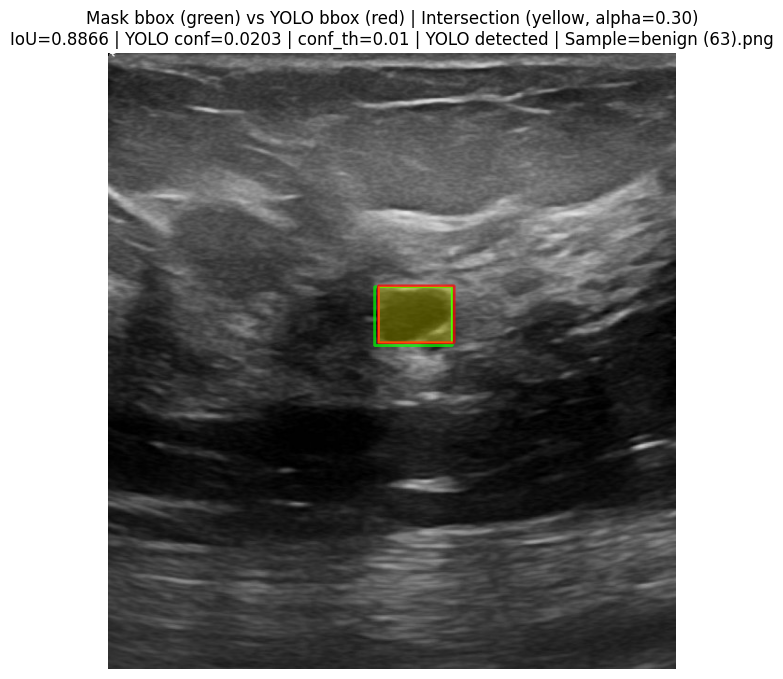

Sample: benign (63).png
Class: benign
IoU: 0.8866
Accuracy (IoU>=0.5): True
Note: detection came from very low threshold (0.01), may be noisy.
YOLO confidence: 0.0203
Used conf threshold: 0.01


In [3]:
# IoU visualization: mask bbox vs YOLO bbox on original image
# Run top cell and YOLO cell first.

if "base_dir" not in globals() or "class_name" not in globals() or "sample_id" not in globals():
    raise ValueError("Run the top cell first so base_dir, class_name, and sample_id are defined.")
if "model" not in globals():
    raise ValueError("Run the YOLO cell first so `model` is available.")

img_path = base_dir / class_name / f"{class_name} ({sample_id}).png"
mask_path = base_dir / f"{class_name}_mask" / f"{class_name} ({sample_id})_mask.png"
if not img_path.exists() or not mask_path.exists():
    raise FileNotFoundError(
        f"Image or mask not found.\nImage: {img_path}\nMask: {mask_path}"
    )

img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ground-truth bbox from mask (cell1 logic)
mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    raise ValueError("No contour found in mask image.")

largest_contour = max(contours, key=cv2.contourArea)
gx, gy, gw, gh = cv2.boundingRect(largest_contour)
gt_xyxy = np.array([gx, gy, gx + gw, gy + gh], dtype=float)


YOLO_CONF_THRESHOLDS = (0.25, 0.10, 0.03, 0.01, 0.003)
YOLO_IMGSZ = 960


def enhance_for_yolo(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blur = cv2.GaussianBlur(enhanced, (0, 0), 1.2)
    sharp = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)
    return cv2.cvtColor(sharp, cv2.COLOR_GRAY2BGR)


def get_yolo_box(image_path, conf_thresholds=YOLO_CONF_THRESHOLDS, imgsz=YOLO_IMGSZ):
    raw_bgr = cv2.imread(str(image_path))
    variants = [
        ("original", raw_bgr),
        ("enhanced", enhance_for_yolo(raw_bgr)),
    ]

    best_box, best_conf, best_th, best_variant = None, -1.0, None, "none"
    for variant_name, variant_bgr in variants:
        for conf_threshold in conf_thresholds:
            results = model.predict(source=variant_bgr, conf=conf_threshold, imgsz=imgsz, verbose=False)
            boxes = results[0].boxes
            if boxes is None or len(boxes) == 0:
                continue
            confs = boxes.conf.cpu().numpy()
            xyxy = boxes.xyxy.cpu().numpy()
            best_idx = int(np.argmax(confs))
            conf_val = float(confs[best_idx])
            if conf_val > best_conf:
                best_box = xyxy[best_idx]
                best_conf = conf_val
                best_th = conf_threshold
                best_variant = variant_name

    if best_box is None:
        return None, 0.0, None, "none"
    return best_box, best_conf, best_th, best_variant


# YOLO bbox on same original image (graceful when no detection)
yolo_xyxy, yolo_conf, used_conf, used_variant = get_yolo_box(img_path)

# IoU + intersection rectangle
if yolo_xyxy is None:
    iou = 0.0
    inter_w, inter_h = 0.0, 0.0
    xA = yA = xB = yB = 0.0
else:
    xA = max(gt_xyxy[0], yolo_xyxy[0])
    yA = max(gt_xyxy[1], yolo_xyxy[1])
    xB = min(gt_xyxy[2], yolo_xyxy[2])
    yB = min(gt_xyxy[3], yolo_xyxy[3])

    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter_area = inter_w * inter_h

    gt_area = max(0.0, (gt_xyxy[2] - gt_xyxy[0])) * max(0.0, (gt_xyxy[3] - gt_xyxy[1]))
    yolo_area = max(0.0, (yolo_xyxy[2] - yolo_xyxy[0])) * max(0.0, (yolo_xyxy[3] - yolo_xyxy[1]))
    union_area = gt_area + yolo_area - inter_area
    iou = inter_area / union_area if union_area > 0 else 0.0

# Draw visualization
vis = img_rgb.copy()
overlay = vis.copy()

# Colors (RGB)
mask_color = (0, 255, 0)      # green
yolo_color = (255, 0, 0)      # red
inter_color = (255, 255, 0)   # yellow

# Draw mask bbox
x1, y1, x2, y2 = gt_xyxy.astype(int)
cv2.rectangle(vis, (x1, y1), (x2, y2), mask_color, 2)

# Draw YOLO bbox only when present
if yolo_xyxy is not None:
    px1, py1, px2, py2 = yolo_xyxy.astype(int)
    cv2.rectangle(vis, (px1, py1), (px2, py2), yolo_color, 2)

# Fill intersection with low opacity
if inter_w > 0 and inter_h > 0:
    ix1, iy1, ix2, iy2 = map(int, [xA, yA, xB, yB])
    cv2.rectangle(overlay, (ix1, iy1), (ix2, iy2), inter_color, thickness=-1)
    alpha = 0.30
    vis = cv2.addWeighted(overlay, alpha, vis, 1 - alpha, 0)

status_text = "YOLO detected" if yolo_xyxy is not None else "YOLO no detection"
conf_text = f"{yolo_conf:.4f}" if yolo_xyxy is not None else "N/A"
used_conf_text = f"{used_conf:.2f}" if used_conf is not None else "N/A"

plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.title(
    f"Mask bbox (green) vs YOLO bbox (red) | Intersection (yellow, alpha=0.30)\n"
    f"IoU={iou:.4f} | YOLO conf={conf_text} | conf_th={used_conf_text} | variant={used_variant} | {status_text} | Sample={img_path.name}"
)
plt.axis("off")
plt.show()

is_correct = iou >= 0.5

print(f"Sample: {img_path.name}")
print(f"Class: {class_name}")
print(f"IoU: {iou:.4f}")
print(f"Accuracy (IoU>=0.5): {is_correct}")
if yolo_xyxy is not None and used_conf == 0.01:
    print("Note: detection came from very low threshold (0.01), may be noisy.")
if yolo_xyxy is None:
    print("YOLO confidence: N/A (no detection)")
    print("Used conf threshold: N/A")
    print("Used variant: N/A")
    print(f"Tried conf thresholds: {YOLO_CONF_THRESHOLDS}")
else:
    print(f"YOLO confidence: {yolo_conf:.4f}")
    print(f"Used conf threshold: {used_conf:.3f}")
    print(f"Used variant: {used_variant}")

Device: cpu
Total training samples (original + crops): 1294
Train / Val / Test: 905 / 194 / 195
Loaded saved model from: unet_busi.pth

Final Test Metrics
Loss      : 0.5077
Dice      : 0.7590
IoU       : 0.6778
Precision : 0.8255
Recall    : 0.7830
Training plots skipped (loaded existing checkpoint).


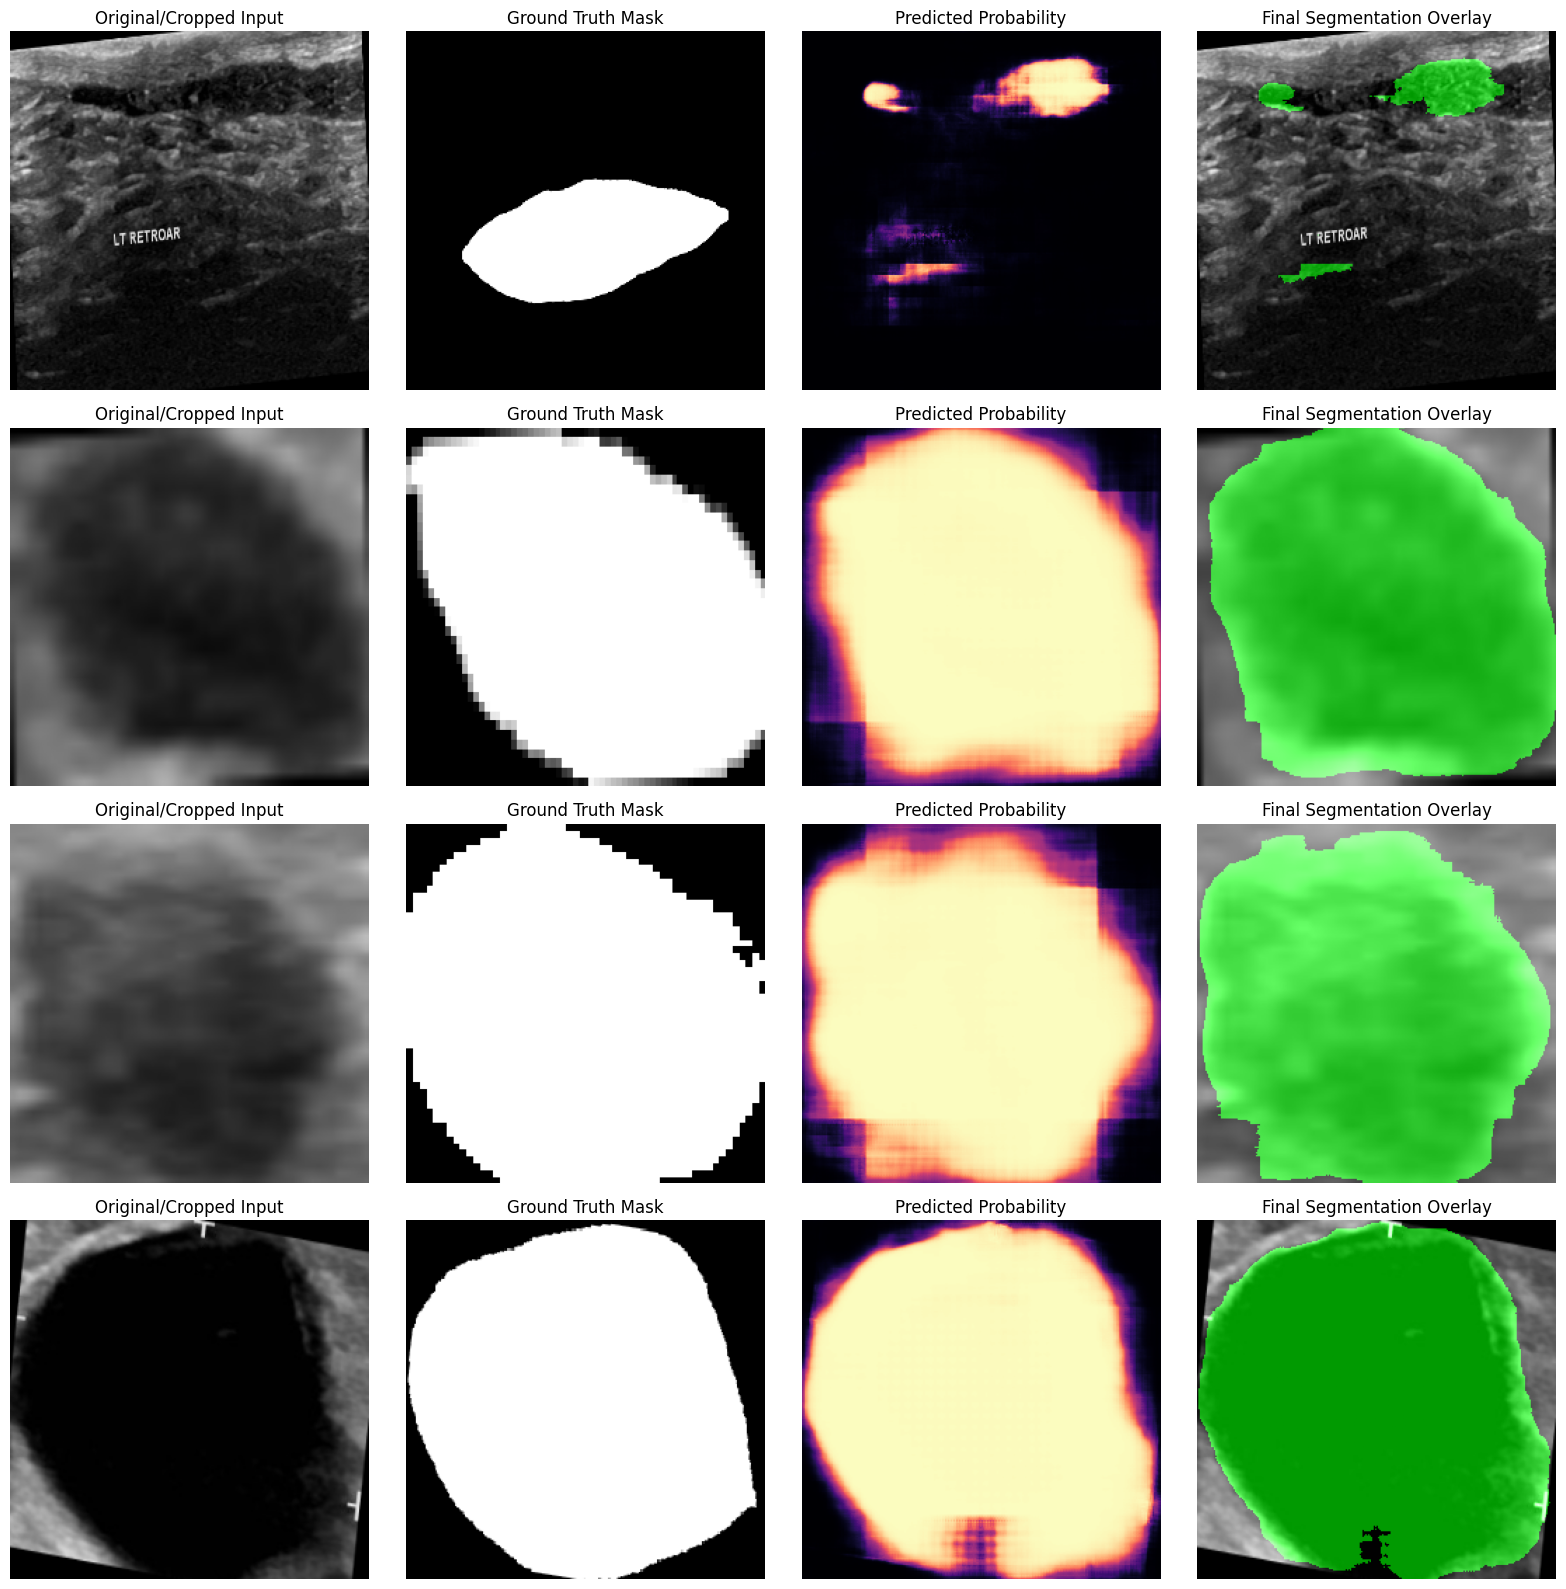

In [4]:
# U-Net segmentation on BUSI (original + cropped ROI samples)
import random
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ------------------------------
# Config
# ------------------------------
SEED = 42
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50
LR = 1e-4
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = Path("unet_busi.pth")
FORCE_RETRAIN = False  # set True to train again even if checkpoint exists

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

base_dir = Path("BUSI_Jpeg")
class_names = ["benign", "malignant"]


# ------------------------------
# Dataset building (original + cropped)
# ------------------------------
def get_bbox_from_mask(mask_gray):
    _, mask_bin = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return x, y, w, h


samples = []
for cls in class_names:
    img_dir = base_dir / cls
    mask_dir = base_dir / f"{cls}_mask"

    for img_path in sorted(img_dir.glob("*.png")):
        mask_path = mask_dir / f"{img_path.stem}_mask.png"
        if not mask_path.exists():
            continue

        mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask_gray is None:
            continue

        # Original sample
        samples.append({"img": img_path, "mask": mask_path, "crop": False, "cls": cls})

        # Cropped ROI sample (using mask bbox)
        bbox = get_bbox_from_mask(mask_gray)
        if bbox is not None:
            x, y, w, h = bbox
            if w > 3 and h > 3:
                samples.append({
                    "img": img_path,
                    "mask": mask_path,
                    "crop": True,
                    "bbox": (x, y, w, h),
                    "cls": cls,
                })

if not samples:
    raise ValueError("No BUSI samples found for training.")

random.shuffle(samples)
N = len(samples)
train_end = int(TRAIN_SPLIT * N)
val_end = int((TRAIN_SPLIT + VAL_SPLIT) * N)

train_samples = samples[:train_end]
val_samples = samples[train_end:val_end]
test_samples = samples[val_end:]

print(f"Device: {DEVICE}")
print(f"Total training samples (original + crops): {N}")
print(f"Train / Val / Test: {len(train_samples)} / {len(val_samples)} / {len(test_samples)}")


class BUSISegDataset(Dataset):
    def __init__(self, sample_list, img_size=256):
        self.sample_list = sample_list
        self.img_size = img_size

    def __len__(self):
        return len(self.sample_list)

    def __getitem__(self, idx):
        row = self.sample_list[idx]

        img = cv2.imread(str(row["img"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(row["mask"]), cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # 1) crop first (for ROI samples)
        if row.get("crop", False):
            x, y, w, h = row["bbox"]
            img = img[y:y+h, x:x+w]
            mask = mask[y:y+h, x:x+w]

        # 2) light augmentation
        if random.random() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)

        if random.random() > 0.5:
            angle = random.randint(-15, 15)
            hh, ww = img.shape[:2]
            M = cv2.getRotationMatrix2D((ww // 2, hh // 2), angle, 1)
            img = cv2.warpAffine(img, M, (ww, hh))
            mask = cv2.warpAffine(mask, M, (ww, hh))

        # 3) resize
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        # 4) normalize
        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        img_t = torch.from_numpy(img.transpose(2, 0, 1))
        mask_t = torch.from_numpy(mask).unsqueeze(0)

        return img_t, mask_t


train_ds = BUSISegDataset(train_samples, IMG_SIZE)
val_ds = BUSISegDataset(val_samples, IMG_SIZE)
test_ds = BUSISegDataset(test_samples, IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


# ------------------------------
# U-Net Model
# ------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        c2 = self.down2(self.pool1(c1))
        c3 = self.down3(self.pool2(c2))

        bn = self.bottleneck(self.pool3(c3))

        u3 = self.up3(bn)
        u3 = torch.cat([u3, c3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, c1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)


def dice_score(pred_bin, target_bin, eps=1e-7):
    inter = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3))
    return ((2.0 * inter + eps) / (union + eps)).mean()


def iou_score(pred_bin, target_bin, eps=1e-7):
    inter = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    total = pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3))
    union = total - inter
    return ((inter + eps) / (union + eps)).mean()


def precision_recall(pred_bin, target_bin, eps=1e-7):
    tp = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    fp = (pred_bin * (1 - target_bin)).sum(dim=(1, 2, 3))
    fn = ((1 - pred_bin) * target_bin).sum(dim=(1, 2, 3))

    precision = ((tp + eps) / (tp + fp + eps)).mean()
    recall = ((tp + eps) / (tp + fn + eps)).mean()
    return precision, recall


def evaluate(model, loader, criterion, measure_time=False):
    model.eval()
    losses, dices, ious, precisions, recalls = [], [], [], [], []
    per_image_times = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            if measure_time:
                if DEVICE == "cuda":
                    torch.cuda.synchronize()
                t0 = time.perf_counter()

            logits = model(imgs)

            if measure_time:
                if DEVICE == "cuda":
                    torch.cuda.synchronize()
                batch_time = time.perf_counter() - t0
                per_image_times.append(batch_time / max(1, imgs.size(0)))

            loss = criterion(logits, masks)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            losses.append(loss.item())
            dices.append(dice_score(preds, masks).item())
            ious.append(iou_score(preds, masks).item())
            p, r = precision_recall(preds, masks)
            precisions.append(p.item())
            recalls.append(r.item())

    out = {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "dice": float(np.mean(dices)) if dices else 0.0,
        "iou": float(np.mean(ious)) if ious else 0.0,
        "precision": float(np.mean(precisions)) if precisions else 0.0,
        "recall": float(np.mean(recalls)) if recalls else 0.0,
    }
    if measure_time and per_image_times:
        out["mean_time_ms"] = float(np.mean(per_image_times)) * 1000.0
        out["fps"] = 1.0 / float(np.mean(per_image_times)) if np.mean(per_image_times) > 0 else 0.0
    return out


model = UNet().to(DEVICE)

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets, smooth=1e-7):
        probs = torch.sigmoid(logits)

        inter = (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

        dice = (2 * inter + smooth) / (union + smooth)
        dice_loss = 1 - dice.mean()

        bce_loss = self.bce(logits, targets)

        return bce_loss + dice_loss

criterion = DiceBCELoss()    

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
}

if MODEL_PATH.exists() and not FORCE_RETRAIN:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"Loaded saved model from: {MODEL_PATH}")
else:
    print("No saved model found (or FORCE_RETRAIN=True). Training U-Net...")
    start = time.time()
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if train_losses else 0.0
        val_metrics = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_iou"].append(val_metrics["iou"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"TrainLoss: {train_loss:.4f} | "
            f"ValLoss: {val_metrics['loss']:.4f} | "
            f"ValDice: {val_metrics['dice']:.4f} | "
            f"ValIoU: {val_metrics['iou']:.4f}"
        )

    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Training time: {time.time() - start:.1f}s")
    print(f"Saved model to: {MODEL_PATH}")

# ------------------------------
# Final test metrics (with timing)
# ------------------------------
test_metrics = evaluate(model, test_loader, criterion, measure_time=True)
print("\nFinal Test Metrics")
print(f"Loss      : {test_metrics['loss']:.4f}")
print(f"Dice      : {test_metrics['dice']:.4f}")
print(f"IoU       : {test_metrics['iou']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
if "mean_time_ms" in test_metrics:
    print(f"Inference : {test_metrics['mean_time_ms']:.2f} ms / image  (~{test_metrics['fps']:.1f} FPS)")

# ------------------------------
# Training plots (only when this run trained)
# ------------------------------
if len(history["train_loss"]) > 0:
    epoch_axis = np.arange(1, EPOCHS + 1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss")
    axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epoch_axis, history["val_dice"], label="Val Dice")
    axes[1].plot(epoch_axis, history["val_iou"], label="Val IoU")
    axes[1].set_title("Segmentation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(epoch_axis, history["val_precision"], label="Val Precision")
    axes[2].plot(epoch_axis, history["val_recall"], label="Val Recall")
    axes[2].set_title("Precision / Recall")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Training plots skipped (loaded existing checkpoint).")

# ------------------------------
# Visualize sample predictions
# ------------------------------
model.eval()
num_show = min(4, len(test_ds))
idxs = np.random.choice(len(test_ds), size=num_show, replace=False) if len(test_ds) > 0 else []

if len(idxs) == 0:
    print("No test samples available for visualization.")
else:
    fig, axes = plt.subplots(num_show, 4, figsize=(16, 4 * num_show))
    if num_show == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row, idx in enumerate(idxs):
            img_t, mask_t = test_ds[idx]
            inp = img_t.unsqueeze(0).to(DEVICE)
            pred = torch.sigmoid(model(inp))[0, 0].cpu().numpy()
            pred_bin = (pred >= 0.5).astype(np.uint8)

            img_np = img_t.permute(1, 2, 0).numpy()
            gt_np = mask_t[0].numpy()

            overlay = img_np.copy()
            overlay[..., 1] = np.clip(overlay[..., 1] + 0.6 * pred_bin, 0, 1)  # green tint

            axes[row, 0].imshow(img_np)
            axes[row, 0].set_title("Original/Cropped Input")
            axes[row, 0].axis("off")

            axes[row, 1].imshow(gt_np, cmap="gray")
            axes[row, 1].set_title("Ground Truth Mask")
            axes[row, 1].axis("off")

            axes[row, 2].imshow(pred, cmap="magma")
            axes[row, 2].set_title("Predicted Probability")
            axes[row, 2].axis("off")

            axes[row, 3].imshow(overlay)
            axes[row, 3].set_title("Final Segmentation Overlay")
            axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Classification with ResNet18 (benign vs malignant) — improved training + metrics
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import cv2
import matplotlib.pyplot as plt

# ------------------------------
# Config
# ------------------------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
HEAD_EPOCHS = 6        # phase 1: train classifier head only (backbone frozen)
FT_EPOCHS = 20         # phase 2: fine-tune full network
HEAD_LR = 1e-3
FT_LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = Path("resnet18_busi_cls.pth")
FORCE_RETRAIN = False  # set True to retrain from scratch

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

base_dir = Path("BUSI_Jpeg")
classes = ["benign", "malignant"]
class_to_idx = {c: i for i, c in enumerate(classes)}

# ------------------------------
# Build sample list (stratified split: same train/val/test ratio per class)
# ------------------------------
per_class_samples = {c: [] for c in classes}
for cls in classes:
    img_dir = base_dir / cls
    for img_path in sorted(img_dir.glob("*.png")):
        per_class_samples[cls].append((img_path, class_to_idx[cls]))

if not any(per_class_samples.values()):
    raise ValueError("No images found for classification.")

train_samples, val_samples, test_samples = [], [], []
for cls, items in per_class_samples.items():
    rng = random.Random(SEED + class_to_idx[cls])
    rng.shuffle(items)
    n = len(items)
    n_train = int(TRAIN_SPLIT * n)
    n_val = int((TRAIN_SPLIT + VAL_SPLIT) * n)
    train_samples.extend(items[:n_train])
    val_samples.extend(items[n_train:n_val])
    test_samples.extend(items[n_val:])

random.Random(SEED).shuffle(train_samples)
random.Random(SEED + 1).shuffle(val_samples)
random.Random(SEED + 2).shuffle(test_samples)

N = len(train_samples) + len(val_samples) + len(test_samples)

print(f"Device: {DEVICE}")
print(f"Total samples: {N}")
print(f"Train / Val / Test: {len(train_samples)} / {len(val_samples)} / {len(test_samples)}")
for split_name, split in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    counts = {c: 0 for c in classes}
    for _, lbl in split:
        counts[classes[lbl]] += 1
    print(f"  {split_name}: " + ", ".join(f"{c}={counts[c]}" for c in classes))


class BUSIClsDataset(Dataset):
    """Stronger but safe augmentations during training; clean transforms at eval."""

    def __init__(self, sample_list, img_size=224, augment=False):
        self.sample_list = sample_list
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.sample_list)

    def __getitem__(self, idx):
        img_path, label = self.sample_list[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.augment:
            # Horizontal flip
            if random.random() < 0.5:
                img = cv2.flip(img, 1)

            # Small rotation
            if random.random() < 0.5:
                angle = random.uniform(-12, 12)
                h, w = img.shape[:2]
                M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
                img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

            # Mild scale + translate (zoom + shift)
            if random.random() < 0.5:
                h, w = img.shape[:2]
                scale = random.uniform(0.92, 1.08)
                tx = random.uniform(-0.04, 0.04) * w
                ty = random.uniform(-0.04, 0.04) * h
                M = np.array([[scale, 0, tx], [0, scale, ty]], dtype=np.float32)
                img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

            # Brightness / contrast jitter (mild)
            if random.random() < 0.5:
                alpha = random.uniform(0.9, 1.1)
                beta = random.uniform(-8, 8)
                img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

            # Gaussian blur (occasional)
            if random.random() < 0.2:
                k = random.choice([3, 5])
                img = cv2.GaussianBlur(img, (k, k), 0)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        img = img.astype(np.float32) / 255.0

        # ImageNet normalization for ResNet18
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std

        img_t = torch.from_numpy(img.transpose(2, 0, 1))
        label_t = torch.tensor(label, dtype=torch.long)
        return img_t, label_t


train_ds = BUSIClsDataset(train_samples, IMG_SIZE, augment=True)
val_ds = BUSIClsDataset(val_samples, IMG_SIZE, augment=False)
test_ds = BUSIClsDataset(test_samples, IMG_SIZE, augment=False)

# Weighted random sampler to keep each batch class-balanced
labels_train = np.array([lbl for _, lbl in train_samples])
class_counts = np.bincount(labels_train, minlength=len(classes)).astype(np.float64)
sample_weights = 1.0 / np.clip(class_counts[labels_train], 1, None)
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


# ------------------------------
# Model: ResNet18 (ImageNet weights), with a small dropout head
# ------------------------------
def build_model():
    try:
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except Exception:
        m = models.resnet18(weights=None)
    in_feats = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_feats, len(classes)),
    )
    return m


model = build_model().to(DEVICE)

# Class-weighted loss + label smoothing
from sklearn.utils.class_weight import compute_class_weight
all_labels = np.array([lbl for _, lbl in train_samples + val_samples + test_samples])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(range(len(classes)))),
    y=all_labels,
)
weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)


# ------------------------------
# Helpers: eval, metrics, ROC/AUC
# ------------------------------
def collect_logits(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    if not all_logits:
        return torch.empty(0, len(classes)), torch.empty(0, dtype=torch.long)
    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)


def run_eval(model, loader):
    logits, labels = collect_logits(model, loader)
    if logits.numel() == 0:
        return 0.0, 0.0, np.zeros(0, dtype=int), np.zeros(0, dtype=int), np.zeros(0, dtype=float)
    loss = criterion(logits.to(DEVICE), labels.to(DEVICE)).item()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(axis=1)
    labels_np = labels.numpy()
    acc = float((preds == labels_np).mean()) if len(labels_np) else 0.0
    # P(positive=malignant)
    score = probs[:, class_to_idx["malignant"]]
    return float(loss), float(acc), labels_np, preds, score


def confusion_matrix_np(y_true, y_pred, num_classes=2):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def binary_clinical_metrics(cm, positive_idx):
    """Return accuracy, sensitivity (recall+), specificity, precision+ for the
    binary case where `positive_idx` marks the positive class.
    """
    total = cm.sum()
    tp = cm[positive_idx, positive_idx]
    fn = cm[positive_idx, :].sum() - tp
    fp = cm[:, positive_idx].sum() - tp
    tn = total - tp - fn - fp
    accuracy = (tp + tn) / total if total > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall on positive
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # recall on negative
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return {
        "accuracy": float(accuracy),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }


def class_metrics_from_cm(cm):
    metrics = {}
    for i, cls_name in enumerate(classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        metrics[cls_name] = {"precision": float(precision), "recall": float(recall), "f1": float(f1)}
    return metrics


def roc_curve_manual(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    order = np.argsort(-y_score)
    y_true = y_true[order]
    P = int(np.sum(y_true == 1))
    N = int(np.sum(y_true == 0))
    if P == 0 or N == 0:
        raise ValueError("ROC needs both positive and negative samples.")
    tps = 0
    fps = 0
    fpr = [0.0]
    tpr = [0.0]
    for yt in y_true:
        if yt == 1:
            tps += 1
        else:
            fps += 1
        fpr.append(fps / N)
        tpr.append(tps / P)
    return np.array(fpr), np.array(tpr)


def auc_trapz(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    trap = getattr(np, "trapz", None)
    if callable(trap):
        return float(trap(y, x))
    return float(np.trapezoid(y, x))


# ------------------------------
# Training (two-phase) with best-checkpoint saving
# ------------------------------
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}


def train_phase(model, optimizer, scheduler, num_epochs, phase_name, best_state, best_val):
    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_losses, correct, total = [], 0, 0
        for imgs, labels in train_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)
            correct += int((preds == labels).sum().item())
            total += int(labels.size(0))

        if scheduler is not None:
            scheduler.step()

        train_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0
        train_acc = correct / total if total > 0 else 0.0
        val_loss, val_acc, y_val_true, _, y_val_score = run_eval(model, val_loader)
        try:
            v_fpr, v_tpr = roc_curve_manual(y_val_true, y_val_score)
            val_auc = auc_trapz(v_fpr, v_tpr)
        except Exception:
            val_auc = float("nan")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        improved = val_acc > best_val
        if improved:
            best_val = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        flag = "  *best*" if improved else ""
        print(
            f"[{phase_name}] Epoch {epoch:02d}/{num_epochs} | "
            f"TrainLoss: {train_loss:.4f} | TrainAcc: {train_acc:.4f} | "
            f"ValLoss: {val_loss:.4f} | ValAcc: {val_acc:.4f} | ValAUC: {val_auc:.4f}{flag}"
        )

    return best_state, best_val


if MODEL_PATH.exists() and not FORCE_RETRAIN:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"Loaded saved classifier from: {MODEL_PATH}")
else:
    print("No saved classifier found (or FORCE_RETRAIN=True). Training ResNet18...")
    t0 = time.time()
    best_val = -1.0
    best_state = None

    # Phase 1: freeze backbone, train fc head
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("fc.")
    head_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(head_params, lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HEAD_EPOCHS)
    best_state, best_val = train_phase(model, optimizer, scheduler, HEAD_EPOCHS,
                                       phase_name="head", best_state=best_state, best_val=best_val)

    # Phase 2: unfreeze all, fine-tune at lower LR
    for p in model.parameters():
        p.requires_grad = True
    optimizer = torch.optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FT_EPOCHS)
    best_state, best_val = train_phase(model, optimizer, scheduler, FT_EPOCHS,
                                       phase_name="ft  ", best_state=best_state, best_val=best_val)

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best checkpoint (val_acc={best_val:.4f})")

    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Training time: {time.time() - t0:.1f}s")
    print(f"Saved classifier to: {MODEL_PATH}")


# ------------------------------
# Test metrics: accuracy, sensitivity, specificity, AUC + per-class metrics + timing
# ------------------------------
# Collect logits + measure per-image inference time
model.eval()
test_logits, test_labels = [], []
infer_times = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        logits = model(imgs)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        infer_times.append((time.perf_counter() - t0) / max(1, imgs.size(0)))
        test_logits.append(logits.cpu())
        test_labels.append(lbls)

test_logits = torch.cat(test_logits, dim=0)
test_labels = torch.cat(test_labels, dim=0)

probs = torch.softmax(test_logits, dim=1).numpy()
y_pred = probs.argmax(axis=1)
y_true = test_labels.numpy()
y_score = probs[:, class_to_idx["malignant"]]
test_loss = criterion(test_logits.to(DEVICE), test_labels.to(DEVICE)).item()

cm = confusion_matrix_np(y_true, y_pred, num_classes=len(classes))
clin = binary_clinical_metrics(cm, positive_idx=class_to_idx["malignant"])
cls_metrics = class_metrics_from_cm(cm)
fpr, tpr = roc_curve_manual(y_true, y_score)
roc_auc = auc_trapz(fpr, tpr)

mean_infer_ms = float(np.mean(infer_times)) * 1000.0
fps_cls = 1.0 / float(np.mean(infer_times)) if np.mean(infer_times) > 0 else 0.0

# Tune classification threshold on validation set (Youden's J) to lift sensitivity / specificity
_, _, y_val_true, _, y_val_score = run_eval(model, val_loader)
try:
    v_fpr, v_tpr = roc_curve_manual(y_val_true, y_val_score)
    # candidate thresholds = sorted unique val scores
    cand = np.sort(np.unique(y_val_score))[::-1]
    best_thr, best_j = 0.5, -1.0
    for thr in cand:
        v_pred = (y_val_score >= thr).astype(int)
        v_cm = confusion_matrix_np(y_val_true, v_pred)
        v_clin = binary_clinical_metrics(v_cm, positive_idx=class_to_idx["malignant"])
        j = v_clin["sensitivity"] + v_clin["specificity"] - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)
except Exception:
    best_thr = 0.5

y_pred_thr = (y_score >= best_thr).astype(int)
cm_thr = confusion_matrix_np(y_true, y_pred_thr, num_classes=len(classes))
clin_thr = binary_clinical_metrics(cm_thr, positive_idx=class_to_idx["malignant"])

print("\nFinal Test Metrics (argmax @ 0.5)")
print(f"Loss        : {test_loss:.4f}")
print(f"Accuracy    : {clin['accuracy']:.4f}")
print(f"Sensitivity : {clin['sensitivity']:.4f}  (recall on malignant)")
print(f"Specificity : {clin['specificity']:.4f}  (recall on benign)")
print(f"AUC (ROC)   : {roc_auc:.4f}")
print(f"Inference   : {mean_infer_ms:.2f} ms / image  (~{fps_cls:.1f} FPS)")
for cls_name in classes:
    m = cls_metrics[cls_name]
    print(f"  {cls_name:<10} Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | F1: {m['f1']:.4f}")

print(f"\nTuned threshold (Youden's J on val): {best_thr:.4f}")
print(f"Accuracy@thr    : {clin_thr['accuracy']:.4f}")
print(f"Sensitivity@thr : {clin_thr['sensitivity']:.4f}")
print(f"Specificity@thr : {clin_thr['specificity']:.4f}")


# ------------------------------
# Training curves
# ------------------------------
if len(history["train_loss"]) > 0:
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(epochs_axis, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_axis, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_axis, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_axis, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_axis, history["val_auc"], label="Val AUC")
    axes[2].set_title("Val AUC over Epochs")
    axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Training curves skipped (loaded existing checkpoint).")


# ------------------------------
# ROC Curve (test set)
# ------------------------------
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})", color="#5DA5DA", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ResNet18 ROC Curve (Test Split)")
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ------------------------------
# Confusion matrix plot (default 0.5 threshold)
# ------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(classes)
ax.set_yticks([0, 1]); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix  (Acc={clin['accuracy']:.3f}, Sens={clin['sensitivity']:.3f}, Spec={clin['specificity']:.3f})")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


# ------------------------------
# Show sample predictions
# ------------------------------
idxs = np.random.choice(len(test_ds), size=min(6, len(test_ds)), replace=False) if len(test_ds) > 0 else []
if len(idxs) == 0:
    print("No test samples available for visualization.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(idxs):
            img_t, label_t = test_ds[idx]
            logits = model(img_t.unsqueeze(0).to(DEVICE))
            prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
            pred_idx = int(np.argmax(prob))

            img_np = img_t.permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
            img_vis = np.clip((img_np * std + mean), 0, 1)

            axes[i].imshow(img_vis)
            axes[i].set_title(
                f"True: {classes[int(label_t)]}\nPred: {classes[pred_idx]} ({prob[pred_idx]:.2f})"
            )
            axes[i].axis("off")

    for j in range(len(idxs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### Batch test (YOLO) — use the web UI

**Batch test is no longer generated offline.** Start the Flask app from the project root, open **`/batch-test`**, and upload images (up to 20). Each tile runs **YOLO detection** (`best.pt`) with the same logic as the main pipeline (confidence sweep, original/enhanced variants).

Optional: the legacy script `scripts/generate_static_batch.py` still builds seg+classification tiles under `webapp/static/batch_gallery/` for offline demos only; it does not power `/batch-test` anymore.


In [ ]:
# Optional: legacy static tile generator (seg + ResNet), not used by /batch-test YOLO UI
# import os, subprocess, sys
# from pathlib import Path
# ROOT = Path(os.getcwd()).resolve()
# assert (ROOT / "webapp" / "app.py").is_file(), "Set cwd to project root"
# subprocess.run(
#     [sys.executable, str(ROOT / "scripts" / "generate_static_batch.py")],
#     cwd=str(ROOT),
#     check=True,
# )
# print("Updated", ROOT / "webapp" / "static" / "batch_gallery")

print("Batch test: run the Flask app and open /batch-test to upload images for YOLO batch detection.")


Wrote 20 tiles → /home/aman/Desktop/HC Project/webapp/static/batch_gallery
Updated /home/aman/Desktop/HC Project/webapp/static/batch_gallery
